# Nonlinear pendulum 

- **Purpose** How does the period of a pendulum change when it is released far from the downward vertical? We compare small and large swings of the same ideal pendulum, starting from rest.  The familiar small-angle model predicts a period independent of amplitude. This notebook measures where that approximation becomes inaccurate and distinguishes physical nonlinearity from numerical error.

- **Approach.** Integrate the full sine restoring force, measure periods from successive downward crossings, and compare them with the exact elliptic-integral expression. Check conservation of mechanical energy and repeat a calculation at tighter tolerances.

Stored figures were rendered with the owner's optional `minimalist` black theme.
Without that separately installed package, rerunning uses Matplotlib's built-in
dark background and explicit figure dimensions. This changes presentation only;
the equations, parameters, scientific calculations, and checks are unchanged.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import minimalist
except ModuleNotFoundError as exc:
    if exc.name != 'minimalist':
        raise
    minimalist = None
from scipy.integrate import solve_ivp
from scipy.special import ellipk

if minimalist is not None:
    minimalist.use_style('black')
else:
    plt.style.use('dark_background')

def figure_size(columns=1, aspect_ratio=None):
    if minimalist is not None:
        if aspect_ratio is None:
            return minimalist.figsize(columns)
        return minimalist.figsize(columns, aspect_ratio=aspect_ratio)
    width = 6.4 * columns
    return (width, width * (0.75 if aspect_ratio is None else aspect_ratio))

## Model

A point mass $M$ hangs from a massless rigid rod of length $L$ in uniform gravity $g$. Motion is confined to a vertical plane. There is no drag, drive, pivot friction, or rod stretching. The angle $\theta$ is measured in radians from the downward vertical, and $\omega$ is its angular velocity in rad s$^{-1}$. The torque equation $ML^2\ddot\theta=-MgL\sin\theta$ gives

$$\dot\theta=\omega,\qquad \dot\omega=-\frac{g}{L}\sin\theta,
\qquad \theta(0)=\theta_0,\quad \omega(0)=0.$$

Mass cancels from the motion but sets the energy scale. We restrict releases to $0<\theta_0<\pi$, which produce oscillations, rather than complete rotations. For comparison, linearizing only the restoring force gives $\theta_{\mathrm{lin}}(t)=\theta_0\cos(\sqrt{g/L}\,t)$ and $T_0=2\pi\sqrt{L/g}$.

We use the adaptive DOP853 integrator. Its tolerances control local error estimates; they are not statistical uncertainty or a guarantee of global error. A maximum integration step of $T_0/8$ helps resolve zero crossings. The regularly spaced output times are for displaying and comparing trajectories, and do not prescribe the adaptive integration steps. The same equations are summarized in [NIST DLMF §22.19](https://dlmf.nist.gov/22.19); integration and event behavior follow the [SciPy solve_ivp documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).

**Model version control name:**

In [2]:
def integrate_pendulum(amplitude_deg, parameters, *, rtol=None, atol=None):
    p = parameters
    theta0 = np.deg2rad(amplitude_deg)
    if not (0 < theta0 < np.pi):
        raise ValueError('Release amplitude must lie strictly between 0 and 180 degrees.')
    if min(p['length'], p['gravity'], p['mass']) <= 0:
        raise ValueError('Length, gravity, and mass must be positive.')
    omega0 = np.sqrt(p['gravity'] / p['length'])
    T0 = 2 * np.pi / omega0
    end = p['duration_T0'] * T0
    times = np.linspace(0, end, p['samples'])

    def rhs(time, state):
        theta, omega = state
        return [omega, -(omega0 ** 2) * np.sin(theta)]

    def downward_crossing(time, state):
        return state[0]

    # Same-direction crossings are one full period apart. Using all crossings
    # without a direction filter would instead measure half a period.
    downward_crossing.direction = -1
    solution = solve_ivp(
        rhs, (0, end), [theta0, 0.0], method='DOP853', t_eval=times,
        events=downward_crossing, max_step=T0 * p['max_step_fraction_T0'],
        rtol=p['rtol'] if rtol is None else rtol,
        atol=p['atol'] if atol is None else atol,
    )
    if not solution.success:
        raise RuntimeError(solution.message)
    if not np.all(np.isfinite(solution.y)):
        raise RuntimeError('The integration produced a non-finite state.')
    crossings = solution.t_events[0]
    if len(crossings) < 3:
        raise ValueError('Increase duration_T0 to obtain at least two complete measured periods.')
    theta, omega = solution.y
    # 2 sin²(theta/2) is equivalent to 1-cos(theta), and avoids cancellation
    # in the small-angle potential energy.
    energy = p['mass'] * (
        0.5 * p['length'] ** 2 * omega ** 2
        + p['gravity'] * p['length'] * 2 * np.sin(theta / 2) ** 2
    )
    return {'amplitude_deg': amplitude_deg, 'theta0': theta0,
            'time_s': solution.t, 'theta_rad': theta, 'omega_rad_s': omega,
            'energy_J': energy, 'relative_energy_error': (energy - energy[0]) / energy[0],
            'period_s': float(np.mean(np.diff(crossings))),
            'measured_cycles': len(crossings) - 1, 'nfev': solution.nfev, 'T0_s': T0}

## Period 

Energy conservation gives $E=ML^2\omega^2/2+MgL(1-\cos\theta)=MgL(1-\cos\theta_0)$. Solving for $\omega$ and integrating one quarter of the orbit yields

$$T=4\sqrt{\frac{L}{2g}}\int_0^{\theta_0}
\frac{d\theta}{\sqrt{\cos\theta-\cos\theta_0}}
=4\sqrt{\frac{L}{g}}\,K(m),\qquad m=\sin^2(\theta_0/2),$$

where $K(m)=\int_0^{\pi/2}(1-m\sin^2\phi)^{-1/2}\,d\phi$. This uses SciPy's **parameter** $m$, the square of the modulus used in some mathematical references; passing the unsquared sine would test the wrong formula. See the [ellipk definition](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ellipk.html).

The numerical period below uses event times from the integrated trajectory, not the plotting grid. The elliptic formula is evaluated separately and is not used to set integration times. As $\theta_0\to0$, $K\to\pi/2$ and $T\to T_0$. As $\theta_0\to\pi^-$, the ideal period diverges because the pendulum spends increasingly long near its unstable upright position; the exact upright release itself remains an equilibrium.

In [3]:
def exact_period(amplitude_deg, parameters):
    amplitude = np.asarray(amplitude_deg, dtype=float)
    if np.any((amplitude < 0) | (amplitude >= 180)):
        raise ValueError('The oscillatory period formula requires 0 <= amplitude < 180 degrees.')
    elliptic_parameter = np.sin(np.deg2rad(amplitude) / 2) ** 2
    return 4 * np.sqrt(parameters['length'] / parameters['gravity']) * ellipk(elliptic_parameter)

## Verification

We compare the event-derived period with the elliptic benchmark at eight release angles. We also monitor the maximum sampled relative energy change $|E(t)-E(0)|/E(0)$ over the integration interval. These checks test different properties: a plausible closed orbit alone is not enough to establish accurate timing.

At $120^\circ$, we repeat the integration with four progressively tighter tolerance settings and with a further reference tolerance. We compare the baseline and reference angles on identical output times. This is a tolerance-sensitivity check for an adaptive solver, not a measured fixed-step convergence order. Energy errors are sampled at the displayed times, so their maximum is not a rigorous continuous-time bound.

The acceptance limits in the parameter dictionary are numerical verification criteria chosen to be much smaller than the amplitude effects of interest. They do not quantify uncertainty in a real apparatus. The calculation is deterministic and uses no random samples.

In [4]:
def analyze(parameters):
    p = parameters
    amplitudes = sorted(set(p['trajectory_angles_deg'] + p['period_angles_deg']))
    runs = {angle: integrate_pendulum(angle, p) for angle in amplitudes}
    rows = []
    for angle in p['period_angles_deg']:
        result = runs[angle]
        exact = float(exact_period(angle, p))
        rows.append({'angle_deg': angle, 'numerical_s': result['period_s'], 'exact_s': exact,
                     'relative_period_error': abs(result['period_s'] / exact - 1),
                     'increase_percent': 100 * (exact / result['T0_s'] - 1),
                     'energy_error': float(np.max(np.abs(result['relative_energy_error'])))})
    check_angle = p['refinement_angle_deg']
    baseline = runs.get(check_angle)
    if baseline is None:
        baseline = integrate_pendulum(check_angle, p)
    exact_check = float(exact_period(check_angle, p))
    refinement = []
    for tolerance in p['refinement_rtols']:
        result = integrate_pendulum(check_angle, p, rtol=tolerance,
                                    atol=tolerance * p['refinement_atol_ratio'])
        refinement.append({'rtol': tolerance, 'period_error': abs(result['period_s'] / exact_check - 1),
                           'energy_error': float(np.max(np.abs(result['relative_energy_error']))),
                           'nfev': result['nfev']})
    reference = integrate_pendulum(check_angle, p, rtol=p['reference_rtol'], atol=p['reference_atol'])
    angle_difference = float(np.max(np.abs(baseline['theta_rad'] - reference['theta_rad'])))
    max_period_error = max(row['relative_period_error'] for row in rows)
    max_energy_error = max(float(np.max(np.abs(run['relative_energy_error']))) for run in runs.values())
    T0 = baseline['T0_s']
    checks = {
        'period_relative_error': max_period_error,
        'sampled_energy_relative_error': max_energy_error,
        'refined_angle_difference_rad': angle_difference,
        'zero_amplitude_period_relative_error': abs(float(exact_period(0, p)) / T0 - 1),
    }
    assert max_period_error < p['accept_period_relative'], checks
    assert max_energy_error < p['accept_energy_relative'], checks
    assert angle_difference < p['accept_angle_difference_rad'], checks
    assert checks['zero_amplitude_period_relative_error'] < 1e-14, checks
    return {'runs': runs, 'period_rows': rows, 'refinement': refinement, 'checks': checks, 'T0_s': T0}

In [5]:
def plot_motion(analysis, parameters):
    fig, axes = plt.subplots(2, 2, figsize=figure_size(1), layout='constrained')
    for row, angle in enumerate(parameters['comparison_angles_deg']):
        result = analysis['runs'][angle]
        time = result['time_s']
        omega0 = 2 * np.pi / result['T0_s']
        linear = result['theta0'] * np.cos(omega0 * time)
        mask = time <= parameters['display_duration_T0'] * result['T0_s']
        ax = axes[row, 0]
        ax.plot(time[mask] / result['T0_s'], np.rad2deg(result['theta_rad'][mask]),
                label='Nonlinear')
        ax.plot(time[mask] / result['T0_s'], np.rad2deg(linear[mask]),
                linestyle='--', label='Small-angle model')
        ax.set(title=f'Release from {angle:g}°', xlabel=r'Time $t/T_0$', ylabel='Angle θ (degrees)')
        ax.legend(loc='lower left', bbox_to_anchor=(0, 1.07), ncol=2)
        ax = axes[row, 1]
        ax.plot(result['theta_rad'], result['omega_rad_s'] / omega0)
        ax.plot([result['theta0']], [0], 'o', zorder=3, label='Release')
        ax.set(title=f'Phase orbit at {angle:g}°', xlabel='Angle θ (rad)',
               ylabel=r'Angular velocity $\omega/\sqrt{g/L}$', xlim=(-np.pi, np.pi), ylim=(-2.15, 2.15))
        ax.legend(loc='upper right')
    return fig


def plot_periods(analysis, parameters):
    fig, axes = plt.subplots(1, 2, figsize=figure_size(1, aspect_ratio=0.5),
                             layout='constrained')
    amplitude = np.linspace(0, parameters['period_curve_max_deg'], 400)
    rows = analysis['period_rows']
    angles = [row['angle_deg'] for row in rows]
    axes[0].plot(amplitude, exact_period(amplitude, parameters) / analysis['T0_s'],
                 label='Exact elliptic period')
    axes[0].plot(angles, [row['numerical_s'] / analysis['T0_s'] for row in rows],
                 'o', markerfacecolor='none', zorder=3, label='Numerical crossings')
    axes[0].axhline(1, color='C2', linestyle='--', label='Small-angle period')
    axes[0].set(xlabel='Release angle (degrees)', ylabel=r'Period $T/T_0$', title='Period versus release angle')
    axes[0].legend()
    errors = np.array([row['relative_period_error'] for row in rows])
    axes[1].semilogy(angles, np.maximum(errors, np.finfo(float).eps), 'o-')
    axes[1].axhline(parameters['accept_period_relative'], color='C1', linestyle='--',
                   label='Acceptance limit')
    axes[1].set(xlabel='Release angle (degrees)', ylabel=r'$|T_{num}/T_{exact}-1|$',
                title='Independent timing check')
    axes[1].legend()
    return fig


def plot_checks(analysis, parameters):
    fig, axes = plt.subplots(1, 2, figsize=figure_size(1, aspect_ratio=0.5),
                             layout='constrained')
    styles = ['-', '--', '-.', ':']
    for index, angle in enumerate(parameters['trajectory_angles_deg']):
        result = analysis['runs'][angle]
        axes[0].plot(result['time_s'] / result['T0_s'], result['relative_energy_error'],
                     linestyle=styles[index % len(styles)], label=f'{angle:g}°')
    axes[0].ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    axes[0].set(xlabel=r'Time $t/T_0$', ylabel=r'$(E(t)-E(0))/E(0)$', title='Sampled energy conservation')
    axes[0].legend(ncol=2)
    rows = analysis['refinement']
    tolerances = [row['rtol'] for row in rows]
    for key, label, marker in [('period_error', 'Period error', 'o'),
                                ('energy_error', 'Sampled energy error', 's')]:
        axes[1].loglog(tolerances, [max(row[key], np.finfo(float).eps) for row in rows],
                       marker=marker, label=label)
    axes[1].invert_xaxis()
    axes[1].set(xlabel='Relative tolerance (tighter →)', ylabel='Relative error',
                title=f'Tolerance sensitivity at {parameters["refinement_angle_deg"]:g}°')
    axes[1].legend()
    return fig

In [6]:
PARAMETERS = {
    'length': 1.0,                     # Rod length in m.
    'gravity': 9.81,                   # Uniform gravitational acceleration in m/s².
    'mass': 1.0,                       # Point mass in kg.
    'trajectory_angles_deg': [10, 60, 120, 170],
    'comparison_angles_deg': [10, 120],  # Two motion panels, drawn from simulated amplitudes.
    'period_angles_deg': [5, 10, 30, 60, 90, 120, 150, 170],
    'duration_T0': 8.0,                 # Integrate for this many small-angle periods.
    'display_duration_T0': 4.0,
    'samples': 2001,                    # Output samples, not fixed integration steps.
    'max_step_fraction_T0': 1 / 8,
    'rtol': 1e-10,
    'atol': 1e-12,                      # Absolute tolerance for rad and rad/s components.
    'refinement_angle_deg': 120,
    'refinement_rtols': [1e-4, 1e-6, 1e-8, 1e-10],
    'refinement_atol_ratio': 0.01,
    'reference_rtol': 1e-12,
    'reference_atol': 1e-14,
    'period_curve_max_deg': 175.0,       # Keep the reference curve below the separatrix.
    'accept_period_relative': 1e-7,
    'accept_energy_relative': 1e-7,
    'accept_angle_difference_rad': 1e-7,
}

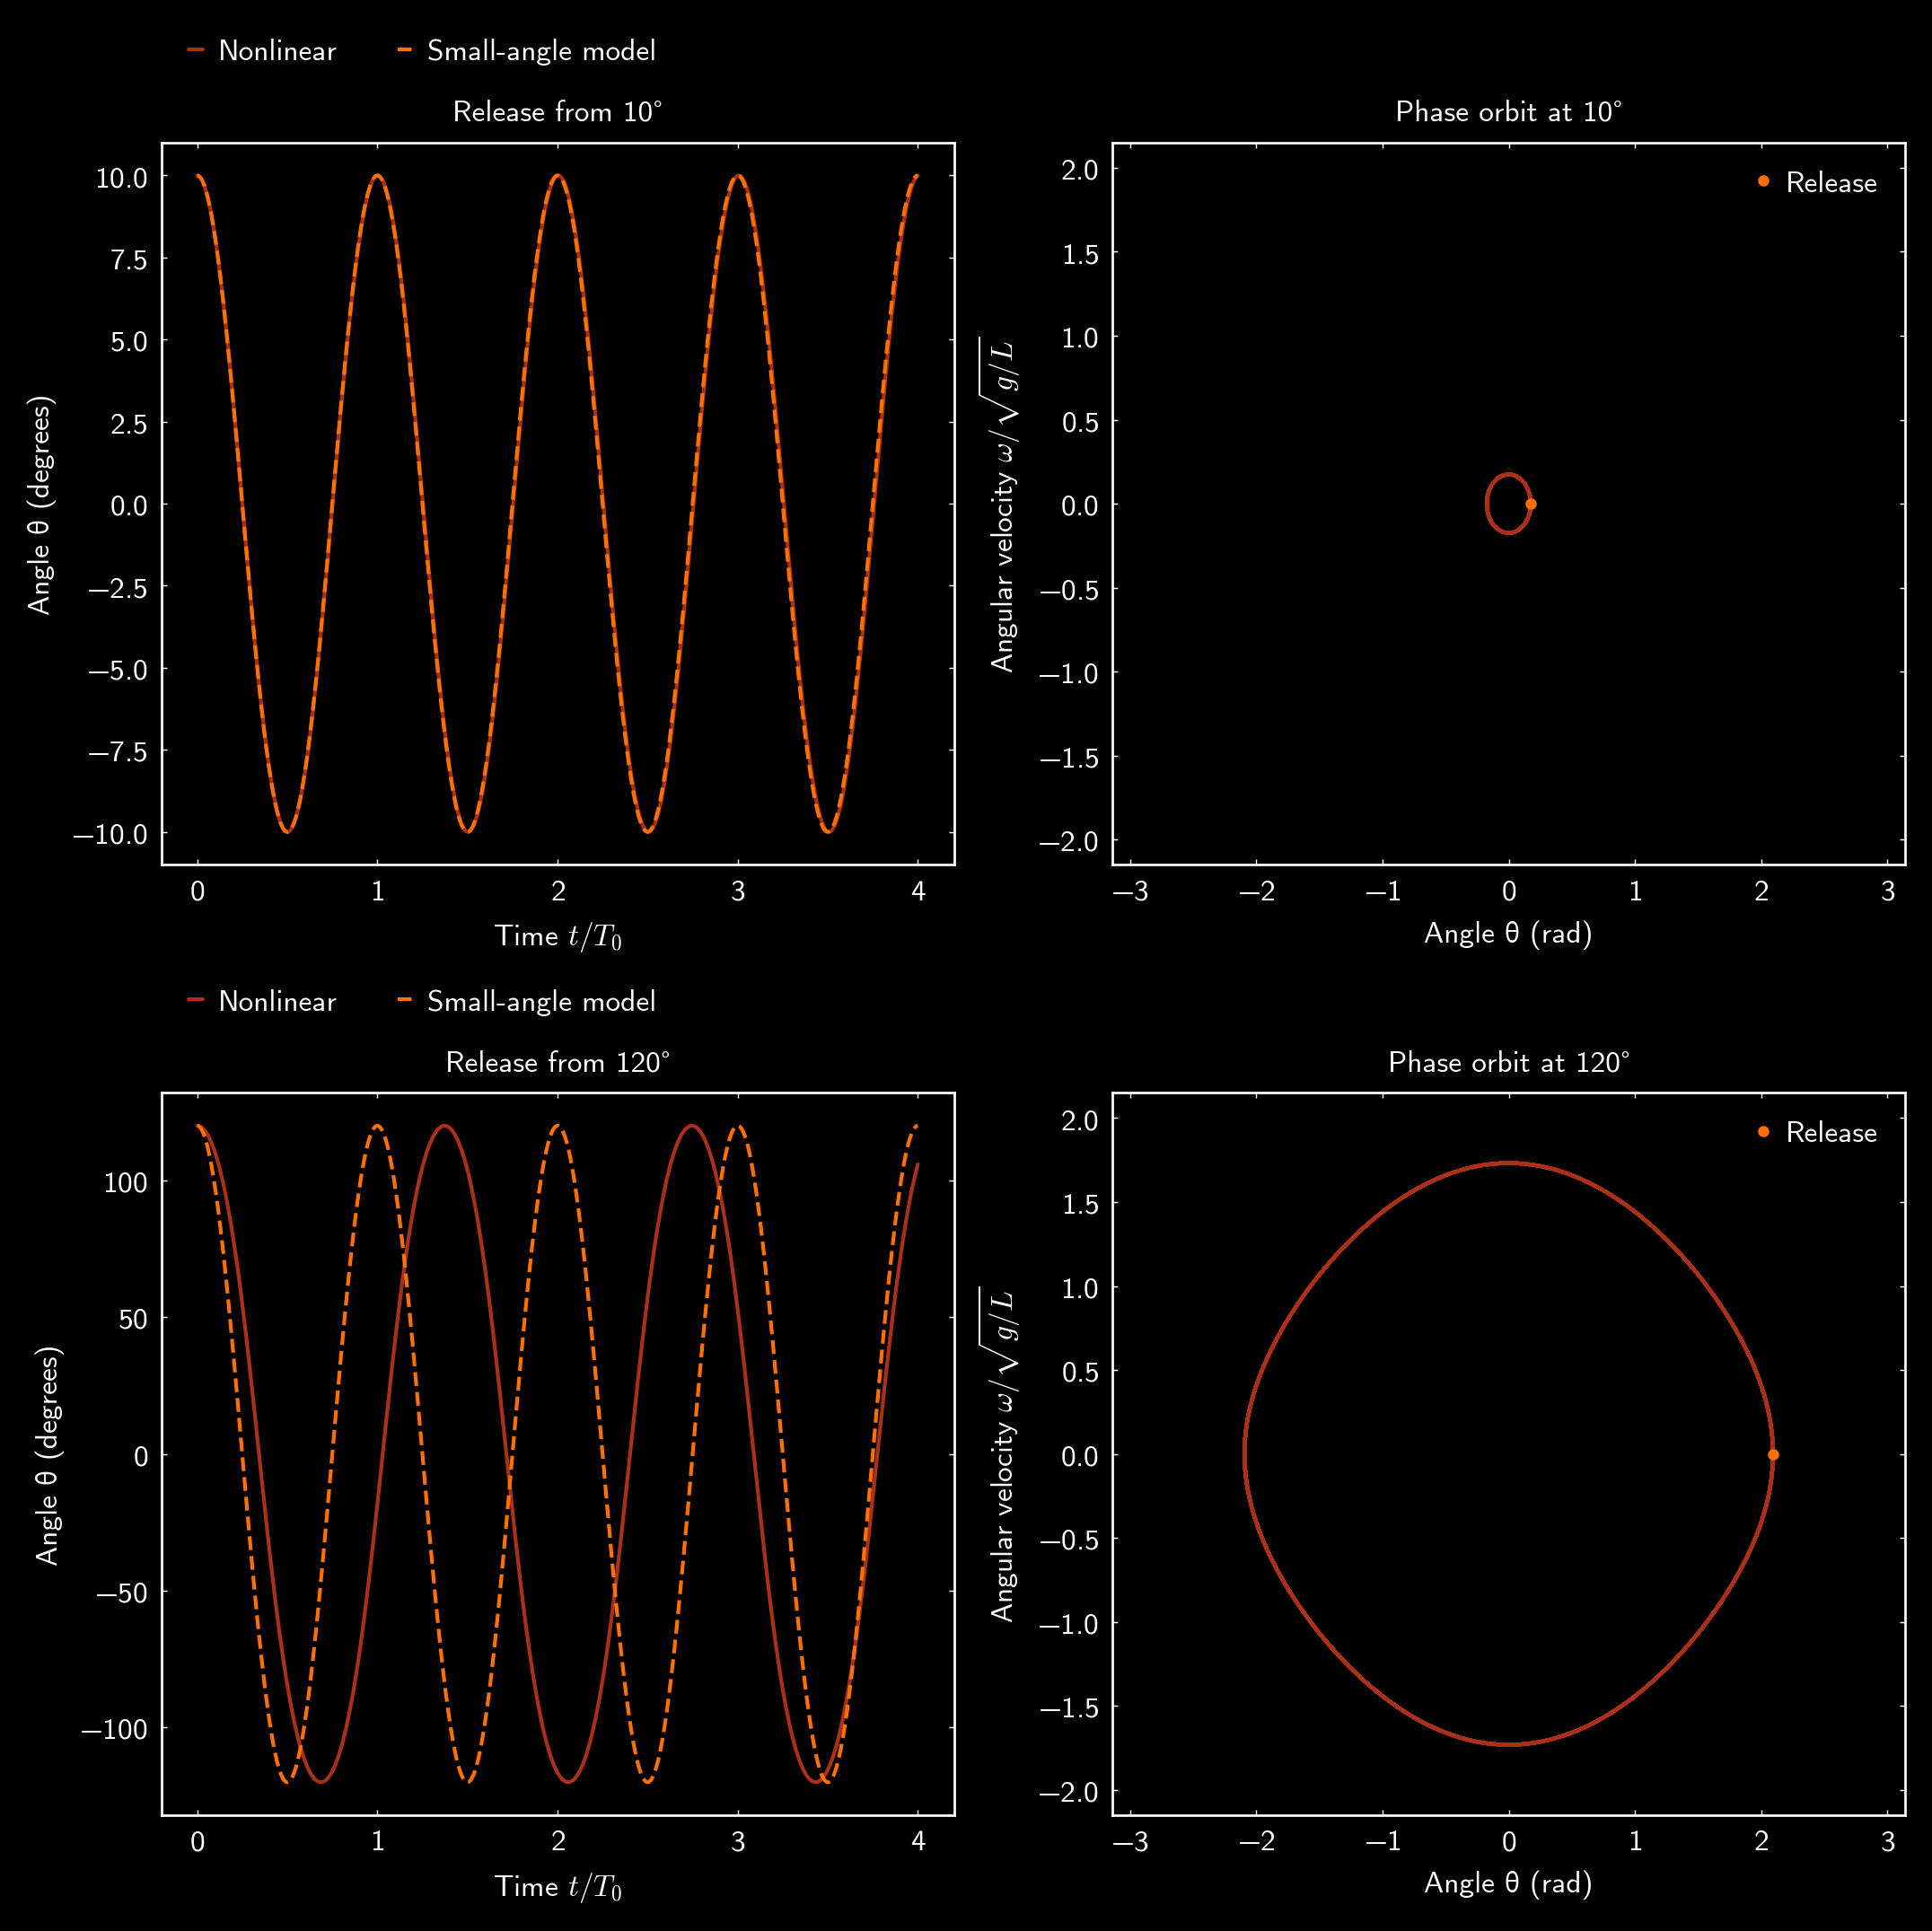

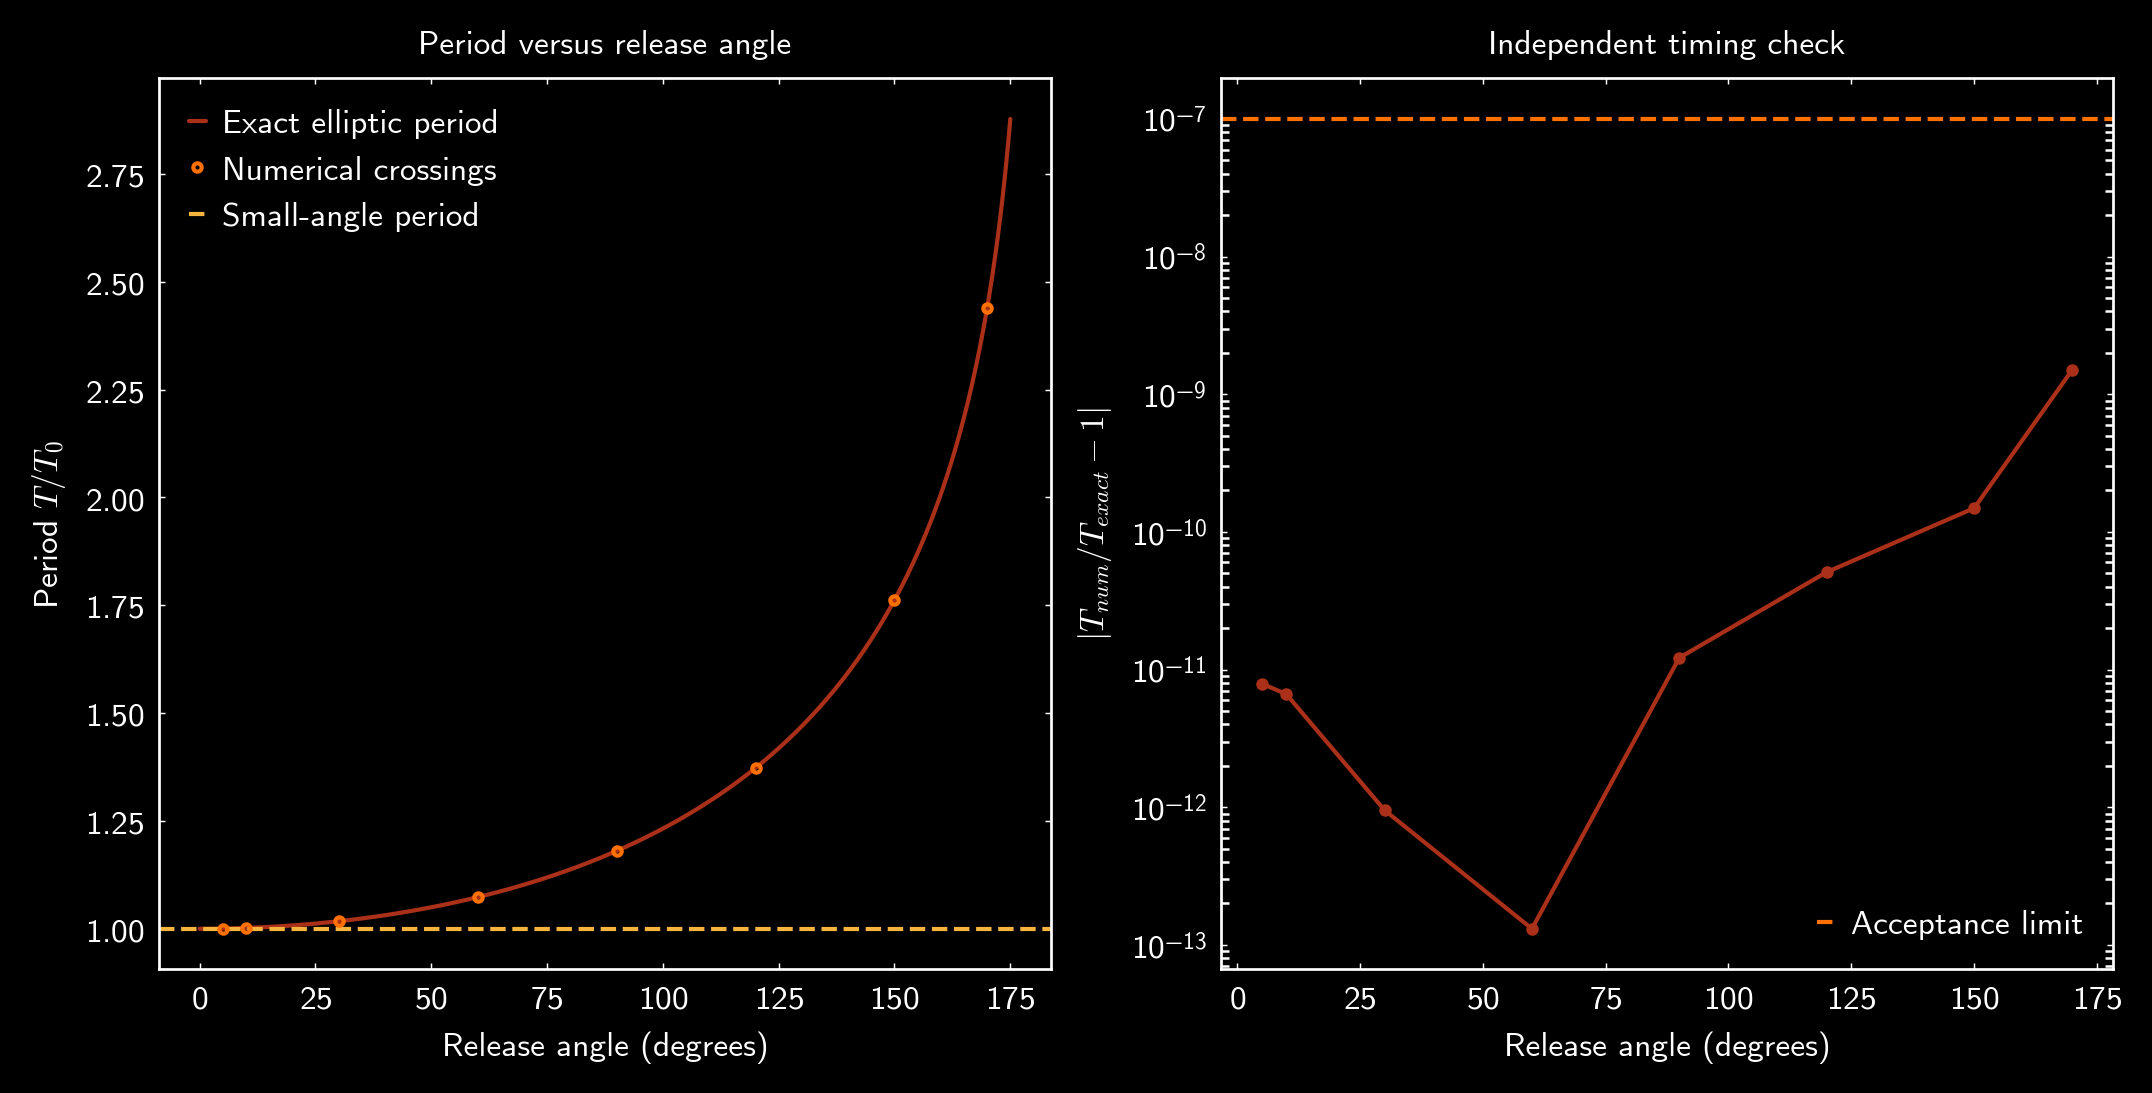

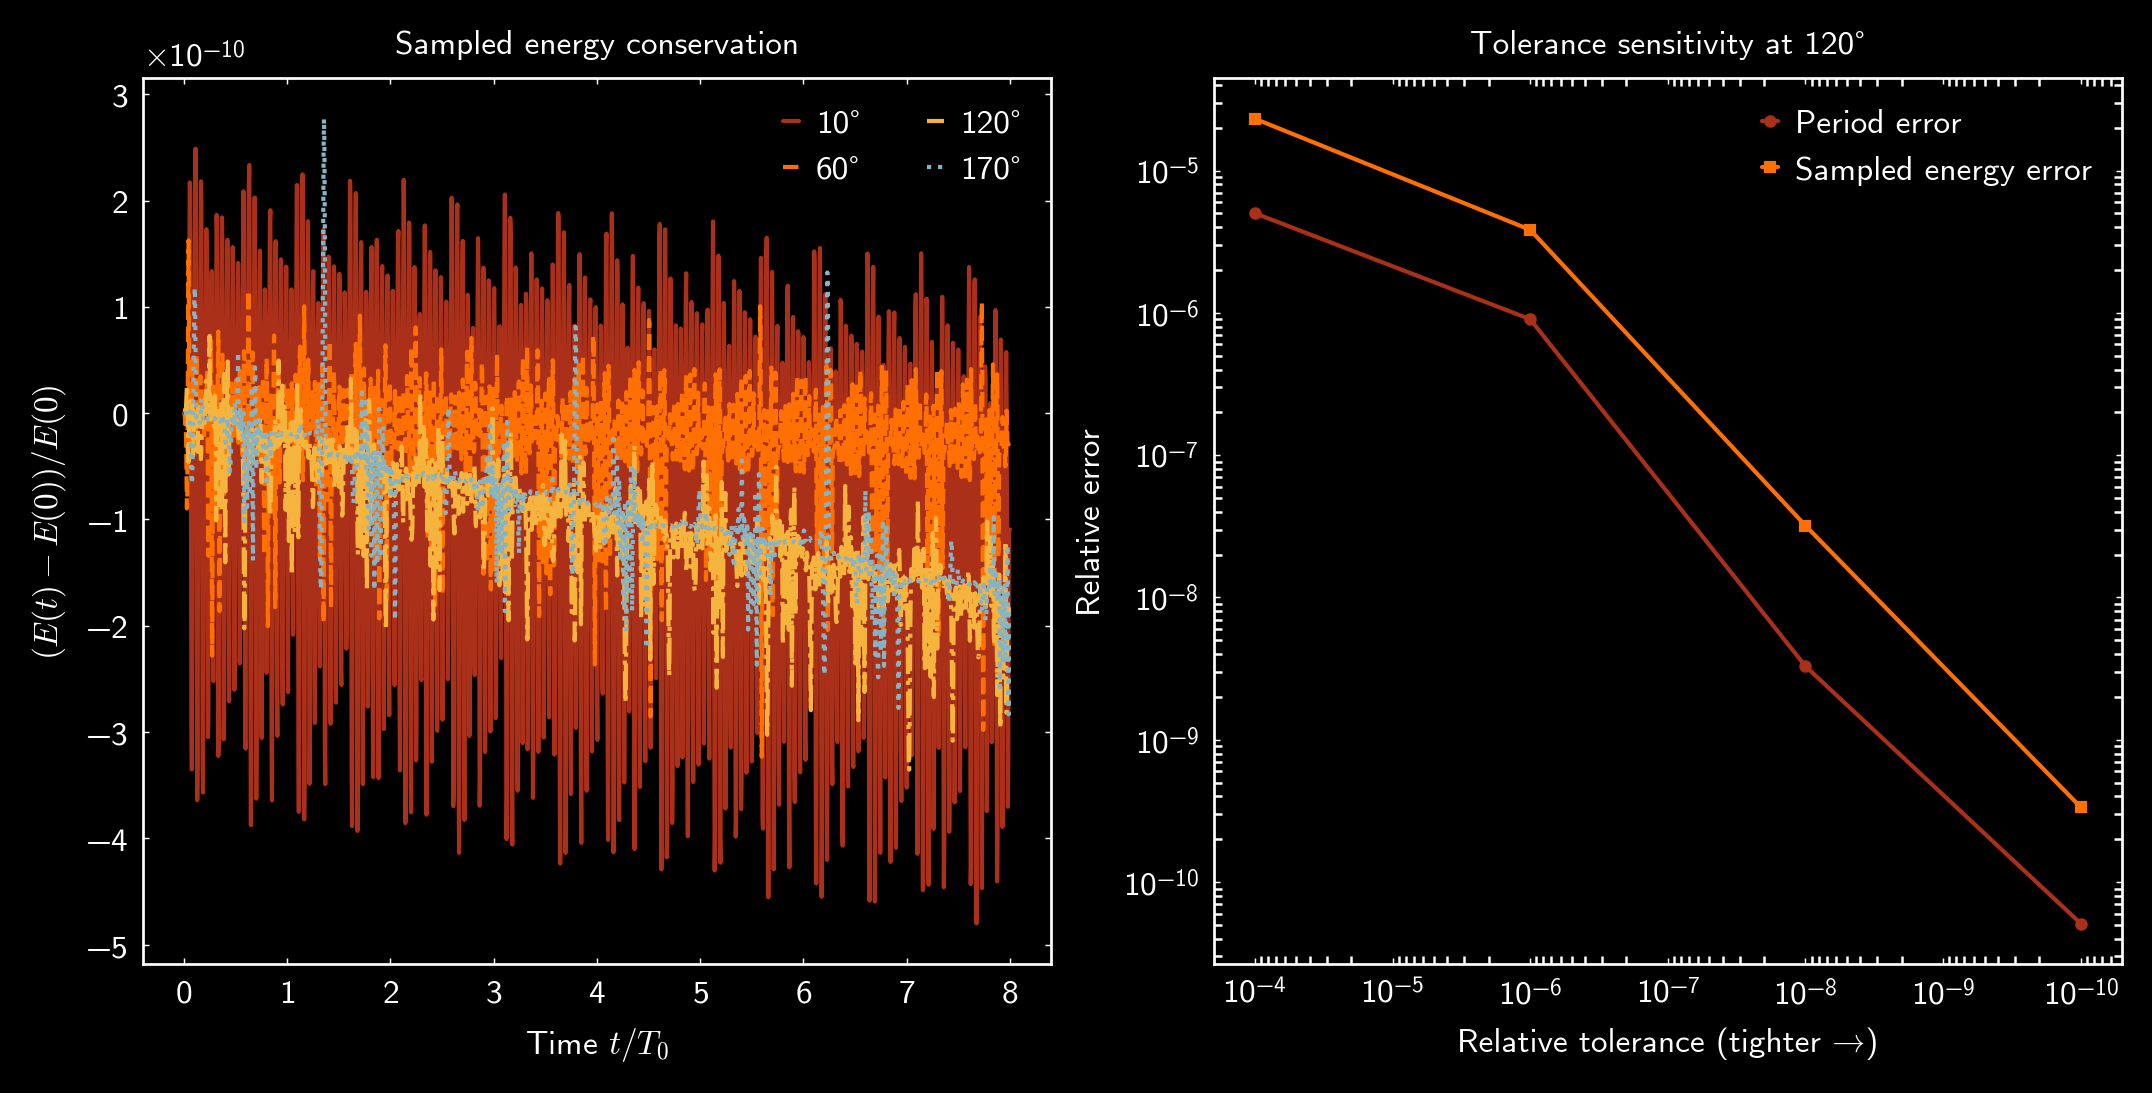

In [7]:
analysis = analyze(PARAMETERS)
motion_figure = plot_motion(analysis, PARAMETERS)
plt.show()

period_figure = plot_periods(analysis, PARAMETERS)
plt.show()

check_figure = plot_checks(analysis, PARAMETERS)
plt.show()